# **Building an Image Classifier with CNN using MNIST **

Build and evaluate a Convolutional Neural Network (CNN) model to classify handwritten digits using the MNIST dataset.

### **Import Libraries and Load Dataset**

In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train_raw = x_train
x_test_raw = x_test

y_train_raw = y_train
y_test_raw = y_test

# Print dataset shapes
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [ ]:
#Data Type Check
print(x_train.dtype)
print(y_train.dtype)

uint8
uint8


In [ ]:
#Pixel Value Range
print("Min:", x_train.min())
print("Max:", x_train.max())

Min: 0
Max: 255


In [ ]:
#Unique Labels Check
print(np.unique(y_train))
#to ensure all digit classes are present


[0 1 2 3 4 5 6 7 8 9]


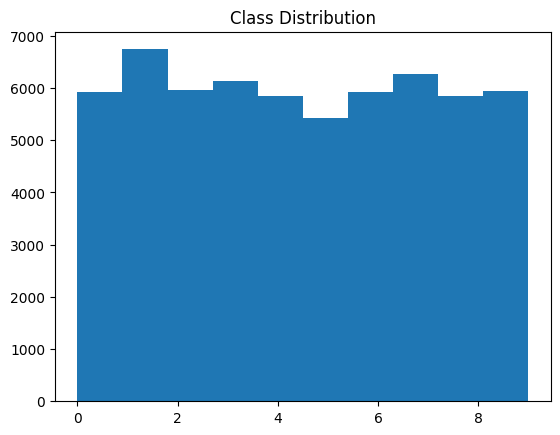

In [ ]:
#Class Distribution
plt.hist(y_train, bins=10)
plt.title("Class Distribution")
plt.show()

From the above class distribution diagram :

*   All bars are almost equal in height
*   Each digit has roughly ~5500 to 7000 samples
*   Thedataset is balanced





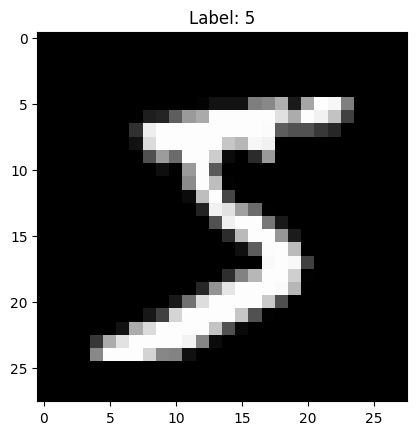

In [ ]:
#Visual Inspection
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
#Missing Values Check
print(np.isnan(x_train).sum())
print(np.isnan(y_train).sum())

0
0


Dataset has no missing values

In [ ]:
#Image Dimension Consistency
print(set(img.shape for img in x_train[:100]))


{(28, 28)}


In [ ]:
#Train-Test Consistency
print(x_train.shape[1:], x_test.shape[1:])

(28, 28) (28, 28)


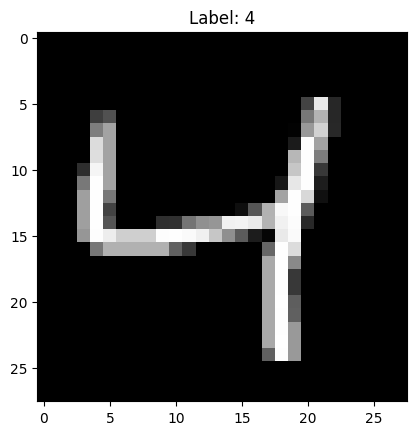

In [ ]:
#Label–Image Alignment Check
index = 2
plt.imshow(x_train[index], cmap='gray')
plt.title(f"Label: {y_train[index]}")
plt.show()
#the image alignment should be correct if the image looks like the number in label

### **Data Preprocessing**

In [ ]:
#Normalize Pixel Values
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

In [ ]:
#Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [ ]:
#One-Hot Encode Labels
#The labels are transformed into one-hot encoded vectors where each class is represented as a binary array
#eg : 3 → [0 0 0 1 0 0 0 0 0 0]

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train_raw, 10).astype("float32")
y_test = to_categorical(y_test_raw, 10).astype("float32")

In [ ]:
#Verify Preprocessed Data

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("Sample pixel value:", x_train[0][0][0])
print("Sample label:", y_train[0])

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
Sample pixel value: [0.]
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


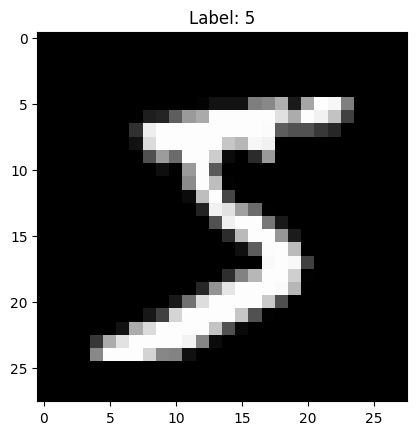

In [ ]:
#Visualize After Normalization

plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(y_train[0])}")
plt.show()




In [ ]:
#Data Type Check

print(x_train.dtype)
print(y_train.dtype)

float32
float32


In [ ]:
#Pixel Value Range

print(x_train.min(), x_train.max())  #expected 0.0 to 1.0

0.0 1.0


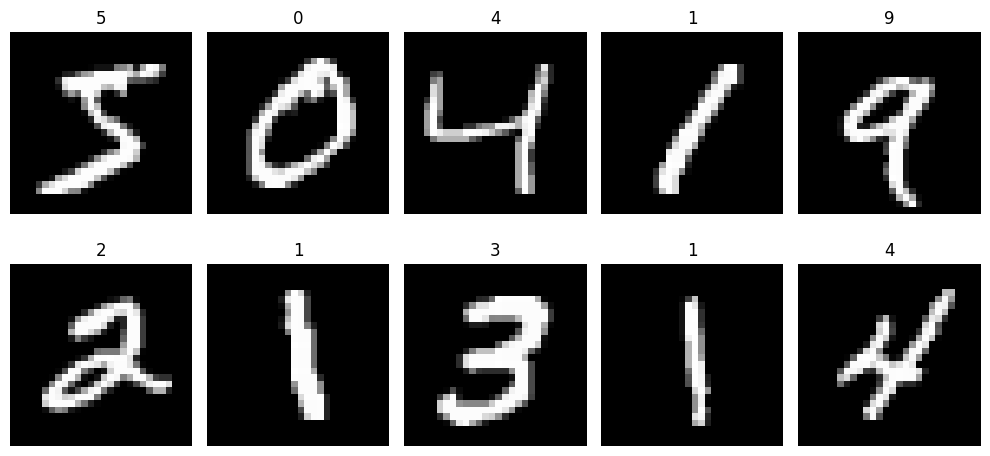

In [ ]:
#Image–Label Alignment
rows = 2
cols = 5  # number of images per row

plt.figure(figsize=(10, 5))

for i in range(rows * cols):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')  # hides axes for cleaner look

plt.tight_layout()
plt.show()

#The image should match the label

In [ ]:
#Missing or Invalid Values
print(np.isnan(x_train).sum())
print(np.isnan(y_train).sum())

#expected 0

0
0


### **Build the CNN Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential(
    [
        # 1. Input Layer
        Input(shape=(28, 28, 1)),

        # 2. Convolution + Pooling Block 1
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.2),

        # 3. Convolution + Pooling Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.2),

        # 4. Flatten Layer
        Flatten(),

        # 5. Fully Connected Layer
        Dense(128, activation='relu'),
        BatchNormalization(),

        # 6. Dropout
        Dropout(0.4),

        # 7. Output Layer
        Dense(10, activation='softmax')
    ]
)
#Compile the model
model.compile( optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'] )

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,154 (1.61 MB)

 Trainable params: 421,898 (1.61 MB)

 Non-trainable params: 256 (1.00 KB)

This model is a Convolutional Neural Network (CNN) designed for image classification. It uses convolutional layers to extract important features from images, followed by max pooling to reduce dimensionality and computation. Dropout layers are included to prevent overfitting, while batch normalization improves training stability and performance. The extracted features are flattened and passed through a dense layer to learn complex patterns, and finally, a softmax output layer predicts the probability of each class.

In [ ]:
from sklearn.model_selection import train_test_split

# Split test into validation + final test
x_val, x_test_final, y_val, y_test_final = train_test_split(
    x_test, y_test, test_size=0.5
)

print(x_val.shape)
print(y_val.shape)
print(x_test_final.shape)
print(y_test_final.shape)

(5000, 28, 28, 1)
(5000, 10)
(5000, 28, 28, 1)
(5000, 10)


### **Train the Model**

In [ ]:
model_train = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 100s 52ms/step - accuracy: 0.9516 - loss: 0.1592 - val_accuracy: 0.9852 - val_loss: 0.0440
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 136s 49ms/step - accuracy: 0.9771 - loss: 0.0748 - val_accuracy: 0.9880 - val_loss: 0.0365
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 48ms/step - accuracy: 0.9817 - loss: 0.0599 - val_accuracy: 0.9888 - val_loss: 0.0316
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 48ms/step - accuracy: 0.9839 - loss: 0.0500 - val_accuracy: 0.9886 - val_loss: 0.0302
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 49ms/step - accuracy: 0.9865 - loss: 0.0429 - val_accuracy: 0.9910 - val_loss: 0.0227
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 88s 47ms/step - accuracy: 0.9872 - loss: 0.0407 - val_accuracy: 0.9908 - val_loss: 0.0218
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 47ms/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9918 - val_loss: 0.0215
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 47ms/step - accuracy: 0

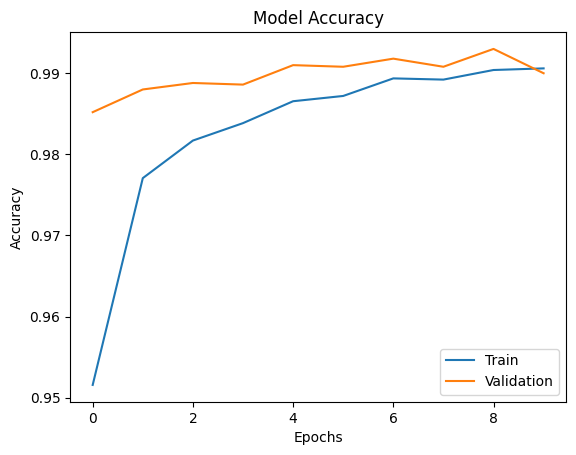

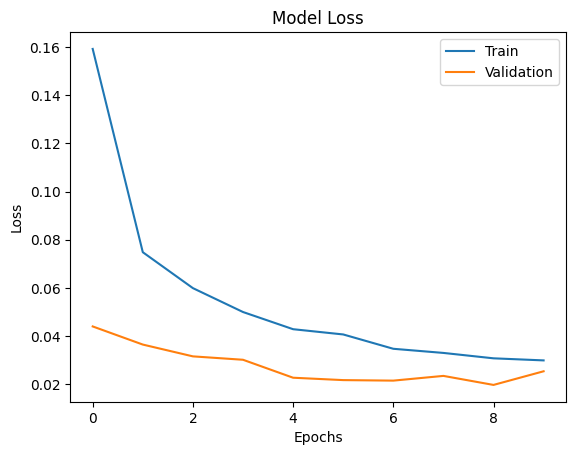

In [ ]:
#Plot training performance
# Accuracy Plot
plt.plot(model_train.history['accuracy'])
plt.plot(model_train.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.plot(model_train.history['loss'])
plt.plot(model_train.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

### **Evaluate the Model**

In [ ]:
#Evaluate on Test Data

test_loss, test_accuracy = model.evaluate(x_test_final, y_test_final)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9928 - loss: 0.0279
Test Loss: 0.027909060940146446
Test Accuracy: 0.9927999973297119


In [ ]:

#Predictions on Test Data
y_pred = model.predict(x_test_final)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_final, axis=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


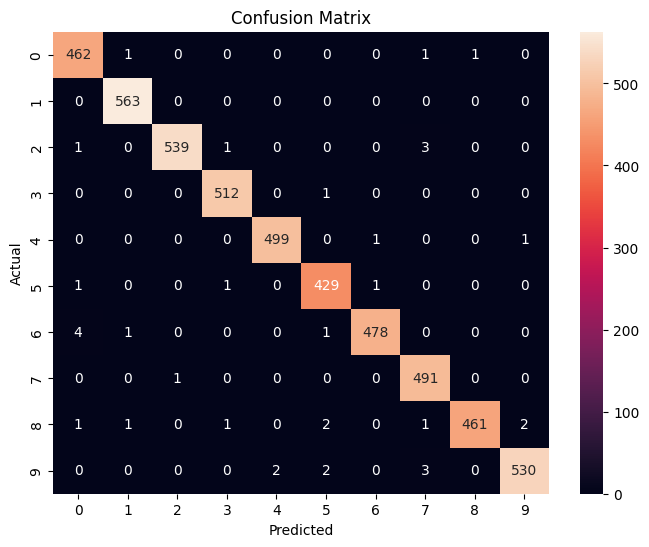

In [ ]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       465
           1       0.99      1.00      1.00       563
           2       1.00      0.99      0.99       544
           3       0.99      1.00      1.00       513
           4       1.00      1.00      1.00       501
           5       0.99      0.99      0.99       432
           6       1.00      0.99      0.99       484
           7       0.98      1.00      0.99       492
           8       1.00      0.98      0.99       469
           9       0.99      0.99      0.99       537

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



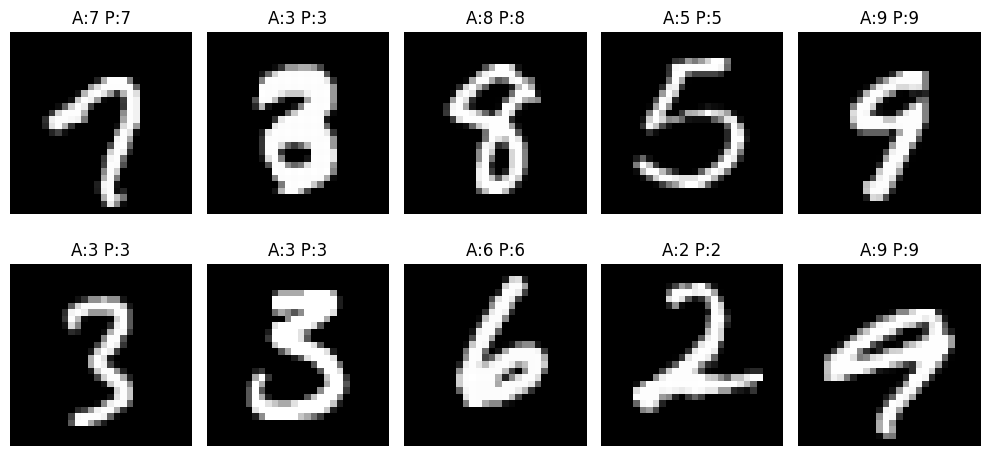

In [ ]:
#Visualize Predictions

import random

plt.figure(figsize=(10,5))

for i in range(10):
    index = random.randint(0, len(x_test_final) - 1)

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_final[index].reshape(28,28), cmap='gray')
    plt.title(f"A:{y_true[index]} P:{y_pred_classes[index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Test the model with custom images**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(path):

    # Load grayscale image
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Blur to reduce noise
    img = cv2.GaussianBlur(img, (5,5), 0)

    # Threshold (binary image)
    _, thresh = cv2.threshold(img, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find contours
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Get largest contour (digit)
    contour = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(contour)

    digit = thresh[y:y+h, x:x+w]

    # Resize while keeping aspect ratio
    if h > w:
        pad = (h - w) // 2
        digit = cv2.copyMakeBorder(digit, 0, 0, pad, pad,
                                   cv2.BORDER_CONSTANT, value=0)
    else:
        pad = (w - h) // 2
        digit = cv2.copyMakeBorder(digit, pad, pad, 0, 0,
                                   cv2.BORDER_CONSTANT, value=0)

    # Resize to 28x28
    digit = cv2.resize(digit, (28, 28))

    # Normalize
    digit = digit / 255.0

    # Reshape
    digit = digit.reshape(1, 28, 28, 1)

    return digit

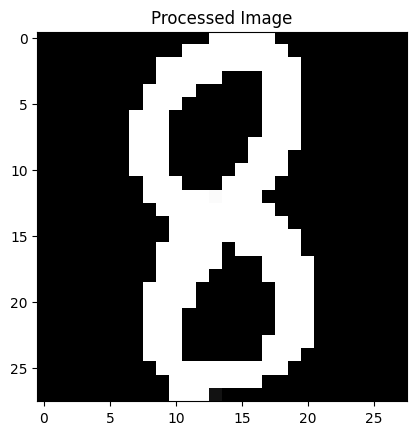

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted: 8


In [ ]:
img = preprocess_image("/content/drive/MyDrive/Test_images/Img_4.jpg")

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title("Processed Image")
plt.show()

pred = model.predict(img)
print("Predicted:", np.argmax(pred))

In [ ]:
import os



#Folder prediction function
def predict_folder(folder_path, model):

    results = {}

    for file in os.listdir(folder_path):

        if file.lower().endswith(('.jpg', '.png', '.jpeg')):

            path = os.path.join(folder_path, file)

            processed = preprocess_image(path)

            if processed is None:
                print(f"{file} → No digit detected ❌")
                continue

            pred = model.predict(processed)
            digit = np.argmax(pred)

            results[file] = digit

            print(f"{file} → Predicted: {digit}")

            # Optional: show image
            plt.imshow(processed.reshape(28,28), cmap='gray')
            plt.title(f"{file} → {digit}")
            plt.axis('off')
            plt.show()

    return results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Img_2.jpg → Predicted: 2


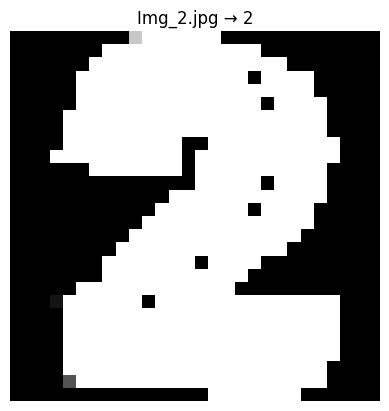

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Img_5.jpg → Predicted: 0


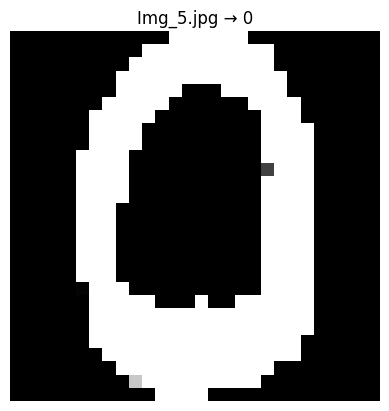

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Img_4.jpg → Predicted: 8


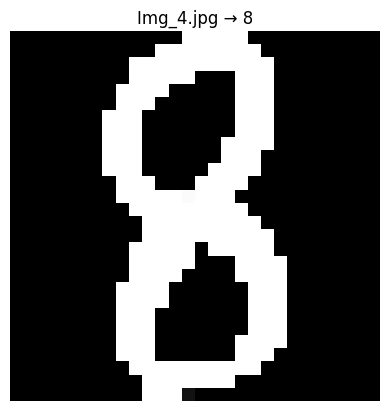

In [ ]:
folder_path = "/content/drive/MyDrive/Test_images"

results = predict_folder(folder_path, model)

In [ ]:
model.save("mnist_model.keras")

**Conclusion**

The CNN model achieved excellent performance on the test dataset with a low test loss of 0.0279 and a high test accuracy of 99.28%, indicating that the model has learned to classify handwritten digits very effectively. The results show strong generalization, meaning the model performs well not only on training data but also on unseen test data. Additionally, the model was successfully tested on custom images and was able to correctly identify them, further confirming its reliability and practical usability. Overall, the model demonstrates high accuracy, stability, and effectiveness for handwritten digit recognition.